In [16]:
# Importing relevant libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Loading in data from file

train_data = pd.read_csv("./input/train.csv")
test_data= pd.read_csv("./input/test.csv")
train_labels=np.array(train_data.loc[:,'label']) # Train labels are the "correct answers" to the training data
train_data=np.array(train_data.loc[:,train_data.columns!='label']) # Train data is the set of 42,000 images of handwritten digits 
train_data = train_data/255
train_data = train_data.reshape(42000, 784) # Turning the training data into a 42,000 x 784 matrix (784 since each image is a 28x28 pixel grid, which is 784 pixels)

# Y will be our "correct answers"

Y = np.zeros(shape=(42000,10))

# Implementing one-hot encoding for the training labels - making it so that it's 42,000 10-D vectors with a "1" entry for the correct digit, and 0s for everything else
for i in range(len(Y)):
    Y[i][train_labels[i]] = 1

correct = []

for i in range(42000):
    correct.append(Y[i:i+1])

Y = correct # a list of 42000 1x10 np arrays
print(Y[0])

[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [17]:
# Defining sigmoid activation function
def sigmoid(Z):
    A = 1/(1+np.exp(-Z))
    return A

# Defining softmax activation function
def softmax(Z):
    Ztransform = Z - np.max(Z, axis = 1, keepdims=True)
    A = np.exp(Ztransform)/(np.sum(np.exp(Ztransform), axis = 1, keepdims=True))
    return A

# Defining logarithmic cost function
def cost(Y, A):
    return (-1/len(Y))* np.sum(Y * np.log(A))

In [18]:
# Forward propogation
def forwardprop(X, weights, biases):
    Zcache = [] # Cache of pre-activations and activations for backprop
    Acache = []

    A = X 

    for i in range(len(weights)):
        
        Z = A @ weights[i] + biases[i] # Essentially Z = X W + b
        Zcache.append(Z)

        if i == len(weights)-1:
            A = softmax(Z) # Final activation uses softmax function
        else:
            A = sigmoid(Z) # All other activation functions are sigmoid

        Acache.append(A)

    return A, Zcache, Acache # Return cache values and final output

In [19]:
# Backpropogation
def backprop(weights, Acache, X, Y): 
    m = Y.shape[0]
    dZ = Acache[-1]-Y # The derivative of cost w.r.t the final pre-activation is A-Y (see theory article)
    dW = [] # Derivatives of cost w.r.t each weight in the network (sorted by layers, added in reverse order)
    db = [] # Derivatives of cost w.r.t each bias in the network (sorted by layers, added in reverse order)

    for i in range(len(weights)-1, -1, -1): # Iterating through weights in reverse order
        if i == 0:
            A_prev = X
        else:
            A_prev = Acache[i-1] # The previous layer of activation
        dWi = 1/(m) * np.transpose(A_prev) @ dZ # Derivative of cost w.r.t a given layer of weights is the previous activation (transposed in this case) multiplied by the derivative of cost w.r.t the pre-activation (see theory article)
        dW.append(dWi)
        dbi = 1/(m) * np.sum(dZ, axis=0, keepdims=True) # Derivative of cost w.r.t a given layer of bias is proportional to the derivative of cost w.r.t the pre-activation (see theory article) 
        db.append(dbi)
        if i > 0:
            dA = dZ @ np.transpose(weights[i]) # The derivative of the cost w.r.t the activation of a layer is the derivative of the cost w.r.t the pre-activations multiplied by the weights of the layer (see theory article)
            dZ = dA*(Acache[i-1]*(1-Acache[i-1])) # The derivative of the cot w.r.t the pre-activation is the derivative of the cost w.r.t the activation multiplied by A(1-A)
    dW = list(reversed(dW)) # Reverse both these lists since the dWs and the dbs were added in reverse order
    db = list(reversed(db))
    return dW, db

In [20]:
def update_parameters(weights, biases, dW, db, alpha): # Gradient descent where alpha is the learning rate
    for i in range(len(weights)):
        weights[i] = weights[i] - alpha*dW[i]
    for i in range(len(biases)):
        biases[i] = biases[i] - alpha*db[i]
    return weights, biases

In [21]:
layers = [784, 128, 10]

weights = []
biases = []

for i in range(len(layers)-1):
    weight = np.random.normal(loc = 0, scale = (layers[i])**(-0.5), size=[layers[i], layers[i+1]])
    weights.append(weight)
    bias = np.zeros(shape=[1,layers[i+1]])
    biases.append(bias)

In [22]:
examples = []
for i in range(42000):
    examples.append(train_data[i:i+1])
print(examples[0].shape)

(1, 784)


In [ ]:
costs = []
iterations = [1,2,3]
costa = 0
for j in range(3):
    costa = 0
    for i in range(42000):
        x = examples[i]
        y = Y[i]

        A, Zcache, Acache = forwardprop(x, weights, biases)
        c = cost(y, A)
        costa += c

        dW, db = backprop(weights, Acache, x, y)

        weights, biases = update_parameters(weights, biases, dW, db, 0.05)
    costa = costa/42000
    costs.append(costa)
    

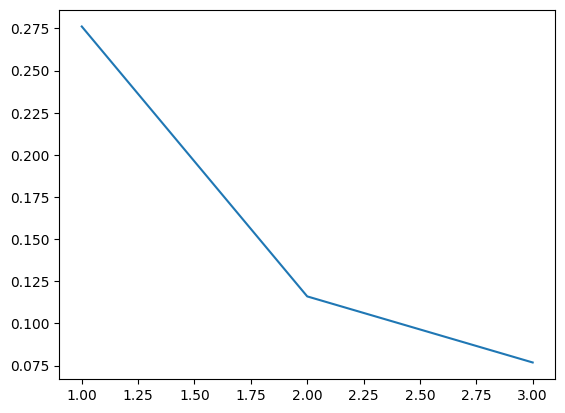

In [25]:
iterations = [1,2,3]
plt.plot(iterations, costs)
plt.show() # Plotting the cost over iterations